📂 LOADING DATA...
✅ Train shape: (10117, 128)
✅ Test shape: (2255, 128)

📊 FEATURE GROUPS:
  Target: yield
  Static features (14): ['STATE', 'X', 'Y']...
  Monthly feature groups:
    GPP: months [1, 2, 3, 4, 5]...
    NDVI: months [1, 2, 3, 4, 5]...
    EVI: months [1, 2, 3, 4, 5]...
    PPT: months [1, 2, 3, 4, 5]...
    TMEAN: months [1, 2, 3, 4, 5]...
    TMIN: months [1, 2, 3, 4, 5]...
    TMAX: months [1, 2, 3, 4, 5]...
    TDMEAN: months [1, 2, 3, 4, 5]...
    VPDMIN: months [1, 2, 3, 4, 5]...
    VPDMAX: months [1, 2, 3, 4, 5]...

🔨 CREATING HORIZON DATASETS...
  Creating horizon h=3...
    Train shape: (10117, 85), Test shape: (2255, 85)
  Creating horizon h=6...
    Train shape: (10117, 115), Test shape: (2255, 115)
  Creating horizon h=9...
    Train shape: (10117, 145), Test shape: (2255, 145)
  Creating horizon h=11...
    Train shape: (10117, 165), Test shape: (2255, 165)

🏃‍♂️ RUNNING MULTI-HORIZON FORECASTING EXPERIMENT

🔬 TRAINING MODEL FOR HORIZON h=3
----------------

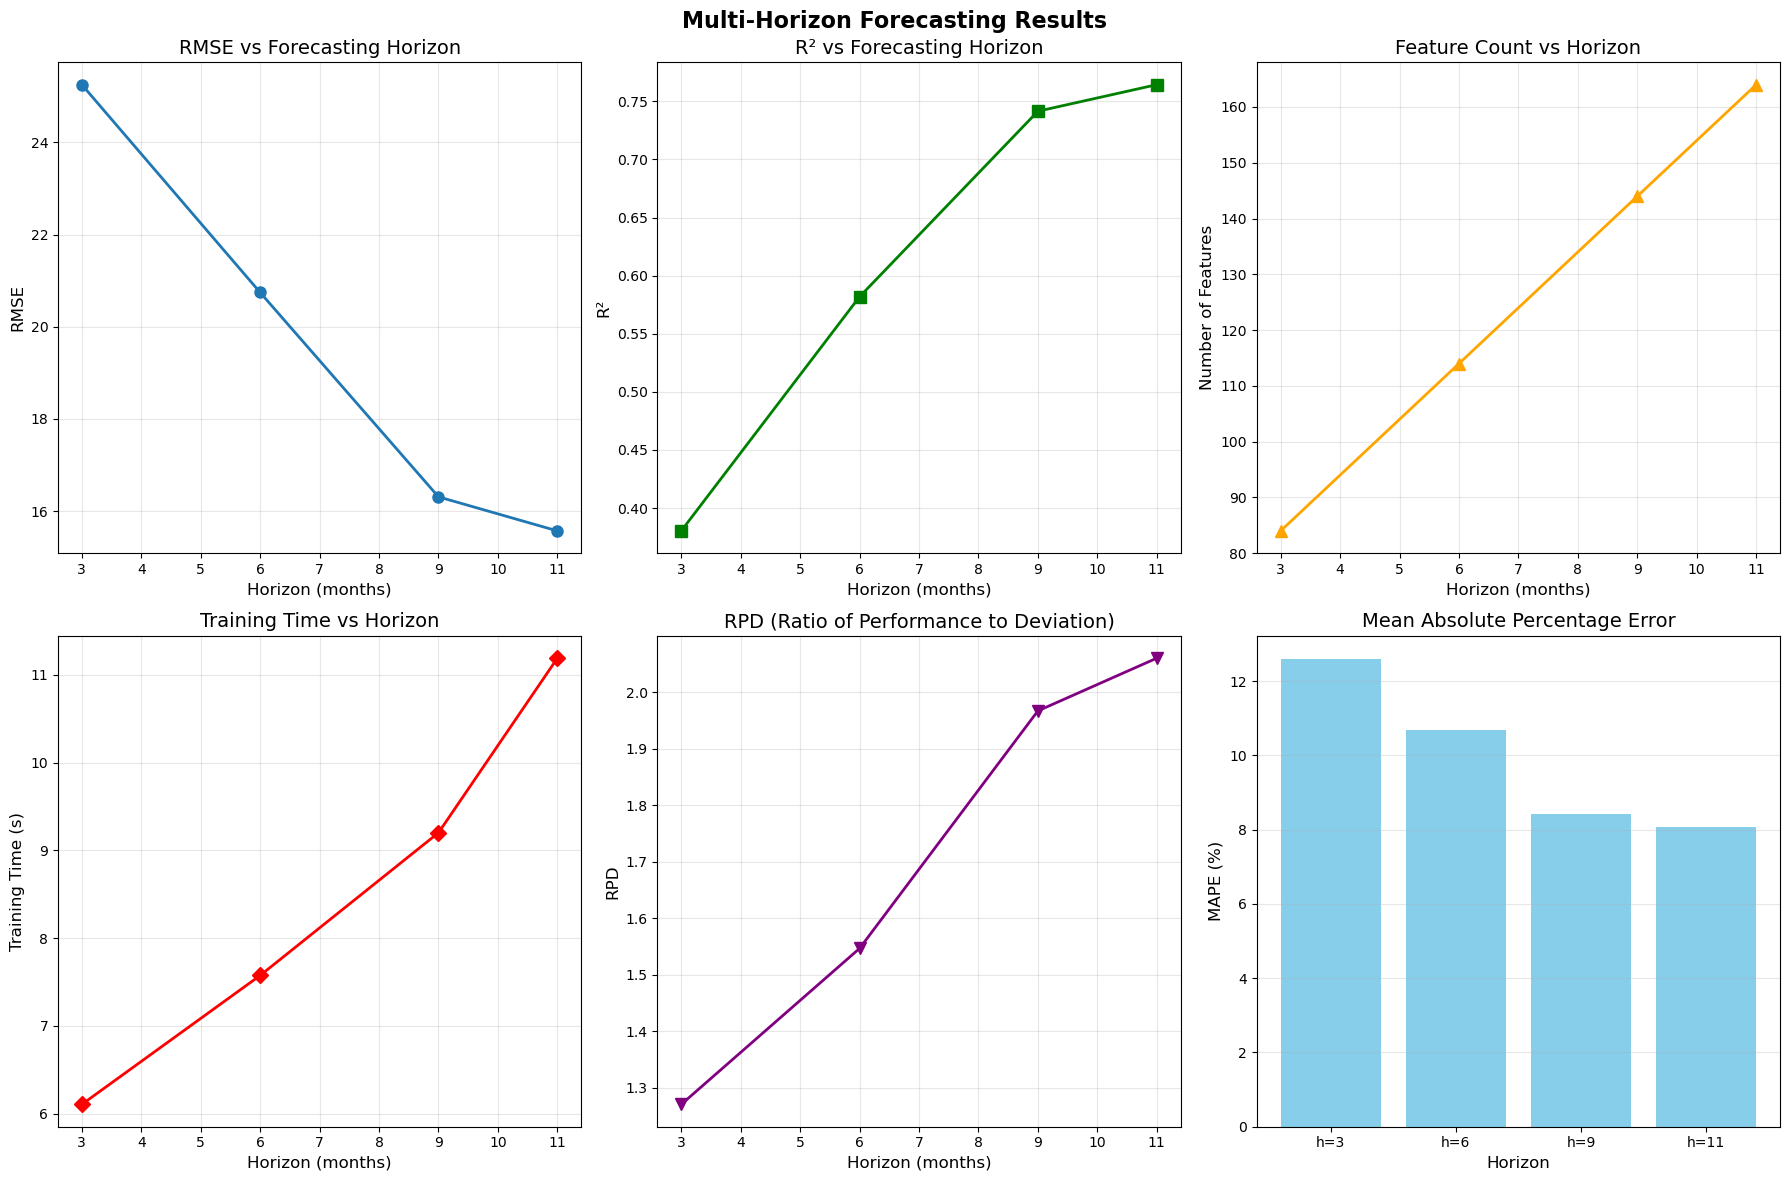


📋 FINAL RESULTS SUMMARY
Horizon   Model  #Feat      RMSE       MAE       R2  MAPE (%)        d      RPD  Train(s)  Infer(s)  #Params        MSE       EV        MBE       Std    Cov95     RPIQ
    h=3 XGBoost     84 25.252300 20.402841 0.380295 12.592567 0.801202 1.270303  6.105153  0.005857     9600 637.678664 0.536875 -12.693376 21.830183 0.908204 1.544414
    h=6 XGBoost    114 20.743005 16.946834 0.581855 10.693020 0.867715 1.546453  7.574497  0.009856     9600 430.272254 0.660676  -9.005957 18.685957 0.933038 1.880152
    h=9 XGBoost    144 16.307853 12.923012 0.741550  8.424330 0.914254 1.967032  9.200674  0.010514     9600 265.946077 0.754660  -3.672923 15.888855 0.940576 2.391486
   h=11 XGBoost    164 15.569208 12.260768 0.764432  8.071879 0.921791 2.060354 11.189745  0.008244     9600 242.400236 0.774823  -3.269904 15.221957 0.940133 2.504944

✅ EXPERIMENT COMPLETED SUCCESSFULLY!
📁 Models saved in: multi_horizon_models/
📊 Results saved in: multi_horizon_models/multi_horizon_r

In [ ]:
# ======================================================
# COMPLETE CODE FOR MULTI-HORIZON FORECASTING WITH XGBOOST
# ======================================================
import os
import numpy as np
import pandas as pd
import time
import warnings
import json
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# Set random seed for reproducibility
SEED = 42
np.random.seed(SEED)

# ======================================================
# 1. DATA LOADING
# ======================================================
print("📂 LOADING DATA...")

# Define paths (using your provided paths)
train_path = r"E:\Abroad period research\New idea for 2026\Corn Yield Estimation\yield_train.csv"
test_path = r"E:\Abroad period research\New idea for 2026\Corn Yield Estimation\yield_test.csv"

# Load datasets
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(f"✅ Train shape: {train_df.shape}")
print(f"✅ Test shape: {test_df.shape}")

# ======================================================
# 2. DEFINE FEATURE GROUPS
# ======================================================
def get_feature_groups(df):
    """Identify static, monthly, and target features"""
    # Target
    target_col = 'yield'
    
    # Static features (soil, location, etc.)
    static_features = [
        'STATE', 'X', 'Y', 'awc', 'aws', 'b_density', 'cec',
        'clay_percent', 'field_capacity', 'organic_matter', 'pH',
        'saturated_hc', 'sand_percent', 'year', 'wilting_point'
    ]
    
    # Monthly feature prefixes
    monthly_prefixes = ['GPP', 'NDVI', 'EVI', 'PPT', 'TMEAN', 'TMIN', 
                       'TMAX', 'TDMEAN', 'VPDMIN', 'VPDMAX']
    
    # All columns in the dataframe
    all_cols = df.columns.tolist()
    
    # Filter existing static features
    existing_static = [col for col in static_features if col in all_cols]
    
    # Find all monthly features for each prefix
    monthly_features = {}
    for prefix in monthly_prefixes:
        prefix_features = [col for col in all_cols if col.startswith(f'{prefix}_') and col[-1].isdigit()]
        if prefix_features:
            monthly_features[prefix] = sorted(prefix_features, 
                                             key=lambda x: int(x.split('_')[-1]))
    
    return target_col, existing_static, monthly_features

# Get feature groups
target_col, static_features, monthly_features = get_feature_groups(train_df)

print(f"\n📊 FEATURE GROUPS:")
print(f"  Target: {target_col}")
print(f"  Static features ({len(static_features)}): {static_features[:3]}...")
print(f"  Monthly feature groups:")
for prefix, features in monthly_features.items():
    print(f"    {prefix}: months {[int(f.split('_')[-1]) for f in features[:5]]}...")

# ======================================================
# 3. CREATE HORIZON-SPECIFIC DATASETS
# ======================================================
def create_horizon_dataset(df, horizon, monthly_features_dict):
    """
    Create dataset for a specific horizon using only months 1..h
    
    Args:
        df: Original dataframe
        horizon: Maximum month to include (3, 6, 9, or 11)
        monthly_features_dict: Dictionary of monthly features by prefix
    
    Returns:
        Dataframe with horizon-specific features
    """
    # Start with static features and target
    horizon_df = df[static_features + [target_col]].copy()
    
    # Add monthly features up to horizon
    for prefix, features in monthly_features_dict.items():
        # Get features for months 1..horizon
        horizon_month_features = [f for f in features if int(f.split('_')[-1]) <= horizon]
        for feature in horizon_month_features:
            horizon_df[feature] = df[feature]
    
    # Create horizon-specific aggregates
    for prefix, features in monthly_features_dict.items():
        # Get features for months 1..horizon
        prefix_features = [f for f in features if int(f.split('_')[-1]) <= horizon]
        
        if prefix_features:
            # Extract the monthly values
            monthly_data = df[prefix_features].values
            
            # Create aggregates (skipna=True)
            horizon_df[f'{prefix}_upto_{horizon}_mean'] = np.nanmean(monthly_data, axis=1)
            horizon_df[f'{prefix}_upto_{horizon}_sum'] = np.nansum(monthly_data, axis=1)
            horizon_df[f'{prefix}_upto_{horizon}_max'] = np.nanmax(monthly_data, axis=1)
            horizon_df[f'{prefix}_upto_{horizon}_std'] = np.nanstd(monthly_data, axis=1)
            # horizon_df[f'{prefix}_upto_{horizon}_count'] = np.sum(~np.isnan(monthly_data), axis=1)
    
    return horizon_df

# Create datasets for each horizon
horizons = [3, 6, 9, 11]
horizon_datasets = {}

print("\n🔨 CREATING HORIZON DATASETS...")
for h in horizons:
    print(f"  Creating horizon h={h}...")
    train_h = create_horizon_dataset(train_df, h, monthly_features)
    test_h = create_horizon_dataset(test_df, h, monthly_features)
    horizon_datasets[h] = {'train': train_h, 'test': test_h}
    print(f"    Train shape: {train_h.shape}, Test shape: {test_h.shape}")

# ======================================================
# 4. COMPREHENSIVE METRICS FUNCTION
# ======================================================
def calculate_all_metrics(y_true, y_pred, model_name, horizon, 
                         train_time, infer_time, n_features, n_params):
    """
    Calculate all metrics including those from your original code
    """
    try:
        # Basic metrics
        mse = mean_squared_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        
        # Percentage metrics
        epsilon = 1e-10
        mape = np.mean(np.abs((y_true - y_pred) / (y_true + epsilon))) * 100
        
        # Advanced statistical metrics
        residuals = y_true - y_pred
        explained_variance = 1 - (np.var(residuals) / (np.var(y_true) + epsilon))
        mbe = np.mean(y_pred - y_true)
        
        # Index of Agreement (d)
        mean_true = np.mean(y_true)
        denominator = np.sum((np.abs(y_pred - mean_true) + np.abs(y_true - mean_true)) ** 2)
        d = 1 - (np.sum(residuals ** 2) / (denominator + epsilon)) if denominator > 0 else 0
        
        # RPD and RPIQ
        rpd = np.std(y_true) / (rmse + epsilon)
        iqr = np.percentile(y_true, 75) - np.percentile(y_true, 25)
        rpiq = iqr / (rmse + epsilon) if rmse > 0 else 0
        
        # Coverage probability
        std_residuals = np.std(residuals) if len(residuals) > 1 else 1.0
        coverage_95 = np.mean((y_pred - 1.96*std_residuals <= y_true) & 
                             (y_true <= y_pred + 1.96*std_residuals))
        
        # Compile metrics dictionary
        metrics = {
            'Horizon': f'h={horizon}',
            'Model': model_name,
            '#Feat': n_features,
            'RMSE': float(rmse),
            'MAE': float(mae),
            'R2': float(r2),
            'MAPE (%)': float(mape),
            'd': float(d),
            'RPD': float(rpd),
            'Train(s)': float(train_time),
            'Infer(s)': float(infer_time),
            '#Params': int(n_params),
            'MSE': float(mse),
            'EV': float(explained_variance),
            'MBE': float(mbe),
            'Std': float(std_residuals),
            'Cov95': float(coverage_95),
            'RPIQ': float(rpiq)
        }
        
        return metrics
        
    except Exception as e:
        print(f"    ⚠️ Metrics calculation error: {e}")
        # Return basic metrics if calculation fails
        return {
            'Horizon': f'h={horizon}',
            'Model': model_name,
            '#Feat': n_features,
            'RMSE': float(rmse) if 'rmse' in locals() else 0.0,
            'MAE': float(mae) if 'mae' in locals() else 0.0,
            'R2': float(r2) if 'r2' in locals() else 0.0,
            'Train(s)': float(train_time),
            'Infer(s)': float(infer_time),
            '#Params': int(n_params)
        }

# ======================================================
# 5. XGBOOST MODEL TRAINING (USING YOUR HYPERPARAMETERS)
# ======================================================
def train_xgboost_for_horizon(train_data, test_data, horizon, model_name="XGBoost"):
    """
    Train XGBoost model for a specific horizon using your hyperparameters
    """
    start_time = time.time()
    
    # Separate features and target
    X_train = train_data.drop(columns=[target_col])
    y_train = train_data[target_col].values
    X_test = test_data.drop(columns=[target_col])
    y_test = test_data[target_col].values
    
    # Get feature names
    feature_names = X_train.columns.tolist()
    n_features = len(feature_names)
    
    # Handle missing values
    X_train = X_train.fillna(X_train.mean())
    X_test = X_test.fillna(X_test.mean())
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Your XGBoost hyperparameters from the provided code
    params = {
        'n_estimators': 300,
        'learning_rate': 0.05,
        'max_depth': 6,
        'min_child_weight': 1,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'reg_alpha': 0.1,
        'reg_lambda': 1.0,
        'random_state': SEED,
        'n_jobs': -1,
        'verbosity': 0
    }
    
    # Train model
    model = xgb.XGBRegressor(**params)
    model.fit(X_train_scaled, y_train)
    
    train_time = time.time() - start_time
    
    # Measure inference time
    inf_start = time.time()
    y_pred = model.predict(X_test_scaled)
    infer_time = time.time() - inf_start
    
    # Count parameters (approximate for XGBoost)
    n_trees = params['n_estimators']
    avg_leaves = 2 ** (params['max_depth'] - 1)
    n_params_approx = n_trees * avg_leaves
    
    # Calculate metrics
    metrics = calculate_all_metrics(y_test, y_pred, model_name, horizon,
                                   train_time, infer_time, n_features, n_params_approx)
    
    return {
        'model': model,
        'scaler': scaler,
        'feature_names': feature_names,
        'metrics': metrics,
        'y_true': y_test,
        'y_pred': y_pred,
        'X_test_scaled': X_test_scaled,
        'X_test_raw': X_test
    }

# ======================================================
# 6. RUN MULTI-HORIZON EXPERIMENT
# ======================================================
print("\n" + "="*80)
print("🏃‍♂️ RUNNING MULTI-HORIZON FORECASTING EXPERIMENT")
print("="*80)

# Store results
all_results = []
horizon_models = {}

# Train separate model for each horizon
for horizon in horizons:
    print(f"\n🔬 TRAINING MODEL FOR HORIZON h={horizon}")
    print("-" * 60)
    
    # Get horizon-specific datasets
    train_h = horizon_datasets[horizon]['train']
    test_h = horizon_datasets[horizon]['test']
    
    print(f"  Train samples: {len(train_h)}")
    print(f"  Test samples: {len(test_h)}")
    print(f"  Features: {train_h.shape[1] - 1} (excluding target)")
    
    # Train XGBoost model
    result = train_xgboost_for_horizon(train_h, test_h, horizon, "XGBoost")
    
    # Store model and results
    horizon_models[horizon] = {
        'model': result['model'],
        'scaler': result['scaler'],
        'feature_names': result['feature_names'],
        'train_data': train_h,
        'test_data': test_h
    }
    
    # Add to results
    all_results.append(result['metrics'])
    
    # Print results for this horizon
    metrics = result['metrics']
    print(f"\n  📊 RESULTS for h={horizon}:")
    print(f"    RMSE: {metrics['RMSE']:.4f}")
    print(f"    MAE: {metrics['MAE']:.4f}")
    print(f"    R²: {metrics['R2']:.4f}")
    print(f"    MAPE: {metrics['MAPE (%)']:.2f}%")
    print(f"    d: {metrics['d']:.4f}")
    print(f"    RPD: {metrics['RPD']:.4f}")
    print(f"    Train time: {metrics['Train(s)']:.2f}s")
    print(f"    Infer time: {metrics['Infer(s)']:.4f}s")
    print(f"    Features: {metrics['#Feat']}")

# ======================================================
# 7. CREATE RESULTS DATAFRAME
# ======================================================
results_df = pd.DataFrame(all_results)

# Reorder columns for better readability
column_order = ['Horizon', 'Model', '#Feat', 'RMSE', 'MAE', 'R2', 
                'MAPE (%)', 'd', 'RPD', 'Train(s)', 'Infer(s)', 
                '#Params', 'MSE', 'EV', 'MBE', 'Std', 'Cov95', 'RPIQ']

# Keep only columns that exist
available_cols = results_df.columns.tolist()
column_order = [col for col in column_order if col in available_cols]
remaining_cols = [col for col in available_cols if col not in column_order]
column_order.extend(remaining_cols)

results_df = results_df[column_order]

# ======================================================
# 8. SAVE MODELS AND RESULTS
# ======================================================
print("\n" + "="*80)
print("💾 SAVING MODELS AND RESULTS")
print("="*80)

# Create directory for saving
output_dir = "multi_horizon_models"
os.makedirs(output_dir, exist_ok=True)
os.makedirs(f"{output_dir}/scalers", exist_ok=True)
os.makedirs(f"{output_dir}/test_data", exist_ok=True)

# Save each horizon model
for horizon in horizons:
    model_info = horizon_models[horizon]
    
    # Save model
    model_path = f"{output_dir}/xgboost_h{horizon}_model.pkl"
    joblib.dump(model_info['model'], model_path)
    
    # Save scaler
    scaler_path = f"{output_dir}/scalers/xgboost_h{horizon}_scaler.pkl"
    joblib.dump(model_info['scaler'], scaler_path)
    
    # Save feature names
    features_path = f"{output_dir}/xgboost_h{horizon}_features.json"
    with open(features_path, 'w') as f:
        json.dump({
            'feature_names': model_info['feature_names'],
            'n_features': len(model_info['feature_names']),
            'horizon': horizon,
            'timestamp': time.strftime("%Y-%m-%d %H:%M:%S")
        }, f, indent=4)
    
    # Save test data sample for analysis
    test_sample = {
        'X_test': model_info['test_data'].drop(columns=[target_col]),
        'y_test': model_info['test_data'][target_col].values
    }
    test_data_path = f"{output_dir}/test_data/h{horizon}_test_data.pkl"
    joblib.dump(test_sample, test_data_path)
    
    print(f"  ✅ Saved horizon h={horizon} model ({len(model_info['feature_names'])} features)")

# Save results
results_path = f"{output_dir}/multi_horizon_results.csv"
results_df.to_csv(results_path, index=False, float_format='%.6f')
print(f"\n✅ Results saved to: {results_path}")

# ======================================================
# 9. VISUALIZE RESULTS
# ======================================================
print("\n" + "="*80)
print("📊 VISUALIZING RESULTS")
print("="*80)

# Create figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Multi-Horizon Forecasting Results', fontsize=16, fontweight='bold')

# 1. RMSE vs Horizon
axes[0, 0].plot(horizons, results_df['RMSE'], 'o-', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Horizon (months)', fontsize=12)
axes[0, 0].set_ylabel('RMSE', fontsize=12)
axes[0, 0].set_title('RMSE vs Forecasting Horizon', fontsize=14)
axes[0, 0].grid(True, alpha=0.3)

# 2. R² vs Horizon
axes[0, 1].plot(horizons, results_df['R2'], 's-', linewidth=2, markersize=8, color='green')
axes[0, 1].set_xlabel('Horizon (months)', fontsize=12)
axes[0, 1].set_ylabel('R²', fontsize=12)
axes[0, 1].set_title('R² vs Forecasting Horizon', fontsize=14)
axes[0, 1].grid(True, alpha=0.3)

# 3. Feature Count vs Horizon
axes[0, 2].plot(horizons, results_df['#Feat'], '^-', linewidth=2, markersize=8, color='orange')
axes[0, 2].set_xlabel('Horizon (months)', fontsize=12)
axes[0, 2].set_ylabel('Number of Features', fontsize=12)
axes[0, 2].set_title('Feature Count vs Horizon', fontsize=14)
axes[0, 2].grid(True, alpha=0.3)

# 4. Training Time vs Horizon
axes[1, 0].plot(horizons, results_df['Train(s)'], 'D-', linewidth=2, markersize=8, color='red')
axes[1, 0].set_xlabel('Horizon (months)', fontsize=12)
axes[1, 0].set_ylabel('Training Time (s)', fontsize=12)
axes[1, 0].set_title('Training Time vs Horizon', fontsize=14)
axes[1, 0].grid(True, alpha=0.3)

# 5. RPD vs Horizon
axes[1, 1].plot(horizons, results_df['RPD'], 'v-', linewidth=2, markersize=8, color='purple')
axes[1, 1].set_xlabel('Horizon (months)', fontsize=12)
axes[1, 1].set_ylabel('RPD', fontsize=12)
axes[1, 1].set_title('RPD (Ratio of Performance to Deviation)', fontsize=14)
axes[1, 1].grid(True, alpha=0.3)

# 6. Bar chart of MAPE
axes[1, 2].bar([f'h={h}' for h in horizons], results_df['MAPE (%)'], color='skyblue')
axes[1, 2].set_xlabel('Horizon', fontsize=12)
axes[1, 2].set_ylabel('MAPE (%)', fontsize=12)
axes[1, 2].set_title('Mean Absolute Percentage Error', fontsize=14)
axes[1, 2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{output_dir}/multi_horizon_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# ======================================================
# 10. PRINT FINAL SUMMARY
# ======================================================
print("\n" + "="*80)
print("📋 FINAL RESULTS SUMMARY")
print("="*80)
print(results_df.to_string(index=False))

print("\n" + "="*80)
print("✅ EXPERIMENT COMPLETED SUCCESSFULLY!")
print("="*80)
print(f"📁 Models saved in: {output_dir}/")
print(f"📊 Results saved in: {results_path}")
print(f"🖼️  Visualizations saved in: {output_dir}/multi_horizon_analysis.png")
print(f"\n📈 PERFORMANCE TRENDS:")
print(f"   - Best R²: h={horizons[np.argmax(results_df['R2'])]} (R²={np.max(results_df['R2']):.4f})")
print(f"   - Best RMSE: h={horizons[np.argmin(results_df['RMSE'])]} (RMSE={np.min(results_df['RMSE']):.4f})")
print(f"   - Features range: {int(results_df['#Feat'].min())} to {int(results_df['#Feat'].max())}")
print("="*80)

# ======================================================
# 11. MODEL LOADING FUNCTION FOR LATER USE
# ======================================================
def load_horizon_model(horizon):
    """Load a specific horizon model for prediction"""
    model_path = f"{output_dir}/xgboost_h{horizon}_model.pkl"
    scaler_path = f"{output_dir}/scalers/xgboost_h{horizon}_scaler.pkl"
    features_path = f"{output_dir}/xgboost_h{horizon}_features.json"
    
    if not os.path.exists(model_path):
        print(f"❌ Model for horizon {horizon} not found!")
        return None
    
    model = joblib.load(model_path)
    scaler = joblib.load(scaler_path)
    
    with open(features_path, 'r') as f:
        features_info = json.load(f)
    
    return {
        'model': model,
        'scaler': scaler,
        'feature_names': features_info['feature_names'],
        'horizon': horizon
    }

print("\n💡 To load a specific horizon model later, use:")
print("   model_info = load_horizon_model(3)  # For horizon h=3")
print("   model = model_info['model']")
print("   scaler = model_info['scaler']")
print("   feature_names = model_info['feature_names']")

h=11 XGBoost    164 15.569208 12.260768 0.764432  8.071879 0.921791 2.060354  9.774817  0.009000     9600 242.400236 0.774823  -3.269904 15.221957 0.940133 2.504944
